# ML Assignment 2 — Heart Disease Risk Classification
**Dataset:** heart_disease_risk_2026.csv (9,000 patients, 25 predictive features, binary target `has_heart_disease`)

This notebook:
1. Loads and preprocesses the dataset
2. Splits into train/test (80/20, stratified)
3. Trains 5 classification models: Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest
4. Evaluates each with Accuracy, AUC, Precision, Recall, F1, MCC
5. Saves fitted pipelines (.pkl) and test_data.csv for the Streamlit app


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

## 2. Load and explore the dataset

In [2]:
df = pd.read_csv("../heart_disease_risk_2026.csv")
print(df.shape)
df.head()

(9000, 27)


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   str    
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64  
 14  che

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

In [4]:
df["has_heart_disease"].value_counts(normalize=True)

has_heart_disease
0    0.697
1    0.303
Name: proportion, dtype: float64

## 3. Preprocessing
Drop the ID column, cast booleans to int, separate numeric vs categorical columns.

In [5]:
TARGET = "has_heart_disease"
df = df.drop(columns=["patient_id"])

bool_cols = df.select_dtypes(include="bool").columns.tolist()
for c in bool_cols:
    df[c] = df[c].astype(int)

X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_cols = ["sex", "chest_pain_type", "smoker_status"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print(f"Numeric features: {len(numeric_cols)}, Categorical features: {len(categorical_cols)}")

Numeric features: 22, Categorical features: 3


## 4. Train / test split (80 / 20, stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Save the raw (unprocessed) test split — used as the assignment's required test_data.csv
test_data = X_test.copy()
test_data[TARGET] = y_test.values
test_data.to_csv("../test_data.csv", index=False)
test_data.shape

(1800, 26)

## 5. Build the shared preprocessing pipeline
StandardScaler for numeric columns, OneHotEncoder for categorical columns.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
    ]
)

## 6. Train all 5 models and evaluate

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8978,0.9497,0.8632,0.7872,0.8234,0.7533
1,Decision Tree,0.8394,0.8917,0.7520,0.7009,0.7255,0.6130
2,kNN,0.8606,0.9143,0.8973,0.6092,0.7257,0.6582
3,Naive Bayes,0.8700,0.9315,0.7686,0.8165,0.7918,0.6981
4,Random Forest (Ensemble),0.8783,0.9354,0.8655,0.7083,0.7790,0.7029


## 7. Confusion matrices for each model

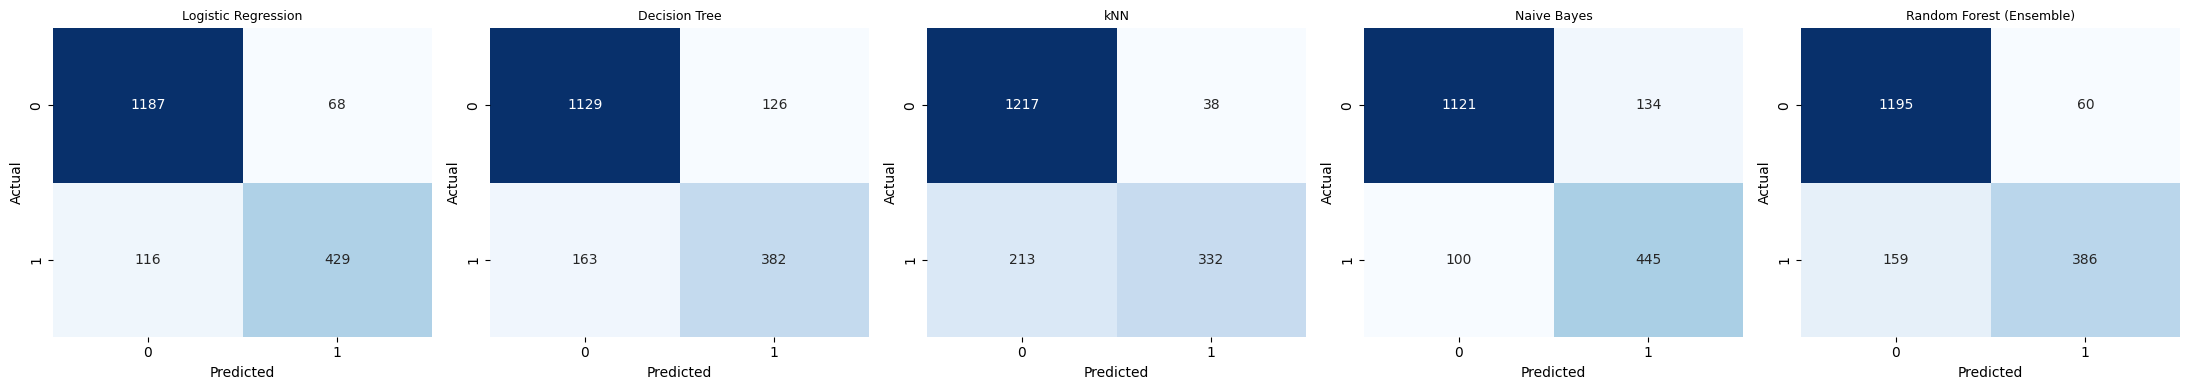

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()

## 8. Save fitted pipelines for the Streamlit app

In [10]:
for name, pipe in fitted_pipelines.items():
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(pipe, f"{safe_name}.pkl")

results_df.to_csv("metrics_comparison.csv", index=False)

schema = {
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "categories": {c: sorted(X[c].unique().tolist()) for c in categorical_cols},
    "target": TARGET,
}
with open("schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved 5 pipelines, metrics_comparison.csv and schema.json")

Saved 5 pipelines, metrics_comparison.csv and schema.json


## 9. Observations
(Fill these in / adjust based on your own run — they will differ slightly by random seed and dataset variant.)